<a href="https://colab.research.google.com/github/StereoWings7/potential-octo-giggle/blob/main/d2l_14_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install d2l

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
#from torch.utils import data
import torchvision
from IPython import display
import time
from d2l import torch as d2l

In [3]:
#必要なデータをd2lモジュールを利用してダウンロード
d2l.DATA_HUB['voc2012'] = (d2l.DATA_URL + 'VOCtrainval_11-May-2012.tar',
                           '4e443f8a2eca6b1dac8a6c57641b67dd40621a49')

voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')

In [4]:
# VOC画像を読み込む関数
def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

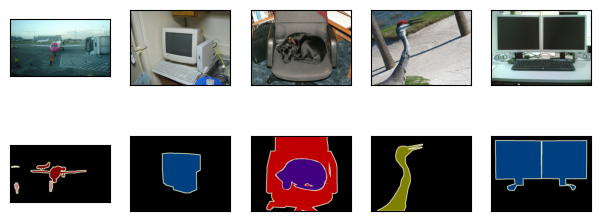

In [ ]:
train_features, train_labels = read_voc_images(voc_dir, True)
n = 5
imgs = train_features[:n] + train_labels[:n]
imgs = [img.permute(1,2,0) for img in imgs]
d2l.show_images(imgs, 2, n);

In [5]:
# RGBの色マップ
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

# VOC_COLORMAPのRGB情報とクラス名を対応付け
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

In [6]:
def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

In [ ]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

In [7]:
def voc_rand_crop(feature, label, height, width):
    """特徴量とラベル画像をランダムにクロップする"""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

In [8]:
class VOCSegDataset(torch.utils.data.Dataset):
    """VOCデータセットを読み込むためのカスタマイズデータセット"""
    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                      *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

In [9]:
# 計算した精度や損失を記録するためのクラス
class Accumulator:
    """n個の変数の和を蓄積する"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 精度計算のための関数
def accuracy(y_hat, y):
    """正しい予測の数を計算する"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = (y_hat.type(y.dtype) == y)
    return float(cmp.sum())

# 時間を測定するクラス
class Timer:
    """複数の実行時間を記録する"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """タイマーを始動"""
        self.tik = time.time()

    def stop(self):
        """タイマーを停止"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """平均時間"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """合計時間"""
        return sum(self.times)

    def cumsum(self):
        """累積時間"""
        return np.array(self.times).cumsum().tolist()

In [10]:
# 描画用のクラス
class Animator:
    """アニメーションでデータをプロット"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 複数の線を増分的にプロット
        if legend is None:
            legend = []
        plt.rcParams['figure.figsize'] = figsize
        self.fig, self.axes = plt.subplots(nrows, ncols)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]

        # axesの設定
        self.config_axes = lambda: self.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def set_axes(self, axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
        """グラフの軸を設定"""
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabel)
        axes.set_xscale(xscale)
        axes.set_yscale(yscale)
        axes.set_xlim(xlim)
        axes.set_ylim(ylim)
        if legend:
            axes.legend(legend)
        axes.grid()

    def add(self, x, y):
        """図に複数のデータポイントを追加"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [20]:
# GPUを使用して精度を評価する関数
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """GPUを使用してモデルのデータセットに対する精度を計算する"""
    if isinstance(net, nn.Module):
        net.eval()  # モデルを評価モードに設定
        if not device:
            device = next(iter(net.parameters())).device
    # 正解の予測数、予測数
    metric = Accumulator(2)

    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

# シングルGPU用のトレーニング関数
def train_net(net, train_iter, test_iter, loss, trainer, num_epochs, device):
    """シングルGPUを使用してモデルをトレーニングする"""
    print('training on', device)
    net.to(device)

    timer = Timer()
    # エポック、訓練損失、訓練精度、テスト精度を描画するためのアニメーター
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                      legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        # 訓練損失の合計、訓練精度の合計、サンプル数、予測数
        metric = Accumulator(4)
        net.train()
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            features, labels = features.to(device), labels.to(device)
            trainer.zero_grad()
            outputs = net(features)
            l = loss(outputs, labels)
            l.sum().backward()
            trainer.step()

            # 損失と精度を計算
            with torch.no_grad():
                metric.add(l.sum(), accuracy(outputs, labels),
                          labels.shape[0], labels.numel())
            timer.stop()

            train_loss, train_acc = metric[0] / metric[2], metric[1] / metric[3]

            if (i + 1) % (len(train_iter) // 5) == 0 or i == len(train_iter) - 1:
                animator.add(epoch + (i + 1) / len(train_iter),
                           (train_loss, train_acc, None))

        # エポック終了時のテスト精度
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))

    print(f'loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {device}')

# 損失関数の定義
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)


In [21]:
# 事前学習済みResNet18モデルを読み込む
pretrained_net = torchvision.models.resnet18(pretrained=True)

# 最後の2層を取り除いたモデルを作成
net = nn.Sequential(*list(pretrained_net.children())[:-2])

# クラス数を設定
num_classes = len(VOC_CLASSES)

# セグメンテーション用に出力層を追加
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

In [22]:
# bilinear_kernelを定義して、転置畳み込み層の重みを初期化するための関数
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

# bilinear upsampling用の重みを設定
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

In [14]:
# データセットの読み込み
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)
batch_size = 16
# num_workersを1以上にするとColabがメモリ不足で死ぬかも
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=0)
test_iter = torch.utils.data.DataLoader(voc_test, batch_size, shuffle=False,
                                    drop_last=True,
                                    num_workers=0)
# この時点でシステムメモリの使用量10.5GB/12.7GBでかなりギリギリ

read 1114 examples
read 1078 examples


loss 0.443, train acc 0.864, test acc 0.855
87.2 examples/sec on cuda


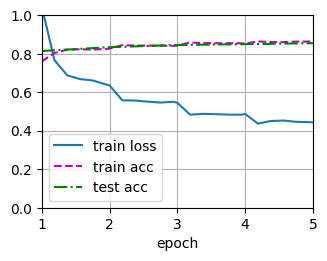

In [23]:
# トレーニングパラメータの設定
num_epochs, lr, wd = 5, 0.001, 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)

# トレーニングの実行
train_net(net, train_iter, test_iter, loss, trainer, num_epochs, device)

In [17]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]


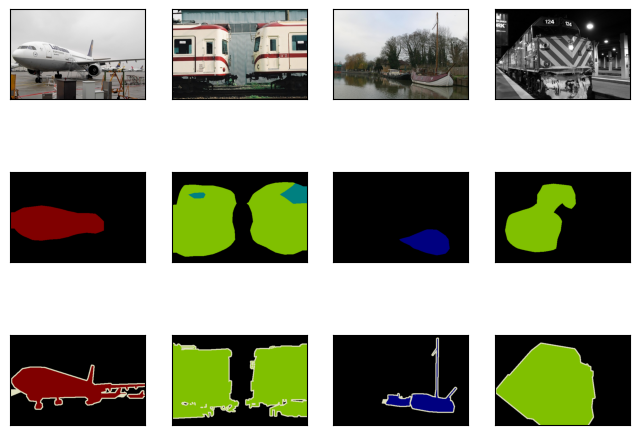

In [24]:
# voc_dir は上で既に定義済み
# voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);
